# Smoking & Drinking Detection — **M4: Hyperparameter Tuning**
### Baseline: **YOLOv8n** · resume on a **new Google account** from the old account's Drive

**Goal.** Continue the YOLOv8n hyperparameter tuning **from where it stopped**, on a different
Google account, reading the dataset and the finished trials from the *old* account's Drive.

**Input:** 640×640 RGB &nbsp;|&nbsp; **Classes:** `smoking (0)`, `drinking (1)` &nbsp;|&nbsp; **Metrics:** Precision, Recall, mAP@50, mAP@50-95

> **The many `best.pt` files are normal.** Each trial saves its own `best.pt`. You never choose one
> by hand — the notebook reads `trial_results.csv`, picks the winner by mAP automatically, and writes
> a single final file to `deliverables/yolov8n_best.pt`. The inventory in §4.0 shows you exactly what
> it found and which trial is currently best.

## 0 · Transferring to a new account — clear step-by-step

Everything (dataset + finished trials) lives in the **OLD** account's Drive. Do this once so the
**NEW** account can read it and continue.

**A. On the OLD account (share the two things):**
1. In Drive, find your **dataset** (the `smoking_drinking_yolo_balanced` folder or `.zip`).
   Right-click → **Share** → add the NEW account's email as **Viewer**.
2. Find your save-point folder **`m4_smoking_drinking_tuning`** (the one containing
   `trial_results.csv` and `trials/`). Right-click → **Share** → add the NEW account as **Viewer**.

**B. On the NEW account (make them visible in My Drive):**
3. Open **Shared with me**. Right-click the **dataset** → **Organize → Add shortcut to Drive** →
   put it in **My Drive**.
4. Right-click the **`m4_smoking_drinking_tuning`** folder → **Add shortcut to Drive** → My Drive,
   and (to avoid a name clash) rename the shortcut to **`m4_from_old_account`**.

**C. In this notebook (on the NEW account):**
5. Run §1 and §2; when prompted, sign in with the **NEW** account to mount its Drive.
6. §2 auto-finds the dataset in your Drive (or set `DATASET_PATH`).
7. §4 sets `RESUME_FROM = .../m4_from_old_account` (the shortcut from step 4) and a fresh
   `CKPT_DIR` in the NEW account's own Drive. §0.1 seeds the finished trials across and lists them.
8. Run the tuning cells — finished trials are **skipped**, only the pending ones train.

**Why a separate `CKPT_DIR`?** A shared shortcut is read-only, so new results are written to the NEW
account's own `m4_smoking_drinking_tuning` folder. After seeding, this account owns copies of the old
trials and no longer depends on the old account.


## 1 · Environment setup
Install Ultralytics + `tqdm`, fix the seed, and confirm the GPU. Safe to re-run.

In [2]:
# Quiet installs — skip anything already present.
%pip -q install "ultralytics>=8.3.0" pandas matplotlib seaborn pyyaml tqdm >/dev/null 2>&1

import os, glob, random, shutil, yaml, json, time, warnings, zipfile
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

import torch
from ultralytics import YOLO
import ultralytics

DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("Ultralytics :", ultralytics.__version__)
print("Torch       :", torch.__version__)
print("CUDA avail. :", torch.cuda.is_available(),
      "|", (torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only"))
print("Using device:", DEVICE)
if DEVICE == "cpu":
    print("\n[!] No GPU detected. Tuning on 100% data on CPU will be VERY slow — "
          "switch Runtime → Change runtime type → GPU.")

Ultralytics : 8.4.107
Torch       : 2.11.0+cu128
CUDA avail. : True | Tesla T4
Using device: 0


## 2 · Mount Google Drive & load the **prepared** dataset
We mount Drive and point at the dataset exported by the data-prep notebook — folder **or** `.zip`
(unzipped once to fast local disk). No cleaning, no re-splitting, no EDA.

```
smoking_drinking_yolo_balanced/
├── data.yaml            # nc: 2, names: ['smoking','drinking']
├── images/{train,val,test}/
└── labels/{train,val,test}/
```

In [4]:
# ── Mount the NEW account's Drive and locate the dataset ─────────────────────
from google.colab import drive
drive.mount("/content/drive")   # sign in with the NEW account

# ← EDIT: path in THIS (new) account's Drive to the dataset (folder OR .zip).
#   This is the shortcut you added in §0 step 3. If wrong, the auto-search below kicks in.
DATASET_PATH = "/content/drive/MyDrive/milestone4_continued../m4_from_old_account.zip"

def _looks_like_dataset(d: Path) -> bool:
    return (d / "data.yaml").exists() and (d / "images" / "train").exists()

def _find_dataset(root: Path):
    """Bounded search: root, children, grandchildren."""
    root = Path(root)
    if _looks_like_dataset(root): return root
    if not root.exists(): return None
    for d in sorted([p for p in root.iterdir() if p.is_dir()]):
        if _looks_like_dataset(d): return d
        for dd in sorted([p for p in d.iterdir() if p.is_dir()]):
            if _looks_like_dataset(dd): return dd
    return None

src = Path(DATASET_PATH)
if src.exists() and src.is_dir() and _looks_like_dataset(src):
    DATASET_DIR = src.resolve()
elif src.exists() and (src.suffix.lower() == ".zip" or src.is_file()):
    DATASET_DIR = (Path("/content") / Path(DATASET_PATH).stem).resolve()
    if not _looks_like_dataset(DATASET_DIR):
        print(f"Unzipping {src} → {DATASET_DIR} …")
        shutil.unpack_archive(str(src), str(DATASET_DIR))
    ff = _find_dataset(DATASET_DIR)
    if ff: DATASET_DIR = ff.resolve()
else:
    print("DATASET_PATH not found — searching your Drive for a YOLO dataset…")
    found = _find_dataset(Path("/content/drive/MyDrive"))
    assert found is not None, (
        "No dataset (data.yaml + images/train) found in My Drive. On the OLD account share it, "
        "then on the NEW account add a shortcut to My Drive (see §0), or set DATASET_PATH.")
    DATASET_DIR = found.resolve()

assert _looks_like_dataset(DATASET_DIR), f"data.yaml / images/train not found under {DATASET_DIR}."
DATA_YAML = DATASET_DIR / "data.yaml"
_meta = yaml.safe_load(DATA_YAML.read_text())
CLASS_NAMES = _meta["names"]
CLASS_NAMES = list(CLASS_NAMES.values()) if isinstance(CLASS_NAMES, dict) else list(CLASS_NAMES)
NC = len(CLASS_NAMES)
print("Dataset dir :", DATASET_DIR)
print("Classes     :", {i: n for i, n in enumerate(CLASS_NAMES)})

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Unzipping /content/drive/MyDrive/milestone4_continued../m4_from_old_account.zip → /content/m4_from_old_account …
Dataset dir : /content/m4_from_old_account
Classes     : {0: 'smoking', 1: 'drinking'}


In [5]:
# Quick integrity check of the full dataset (counts only — NOT EDA/preprocessing).
def split_counts(root: Path):
    rows = []
    for sp in ["train", "val", "test"]:
        imgs = list((root / "images" / sp).glob("*.*"))
        lbls = list((root / "labels" / sp).glob("*.txt"))
        inst = {c: 0 for c in range(NC)}
        for lb in lbls:
            for ln in lb.read_text().splitlines():
                if ln.strip():
                    inst[int(float(ln.split()[0]))] += 1
        rows.append({"split": sp, "images": len(imgs), "label_files": len(lbls),
                     **{CLASS_NAMES[c]: inst[c] for c in range(NC)}})
    return pd.DataFrame(rows)

df_counts = split_counts(DATASET_DIR)
display(df_counts)
TRAIN_IMAGES = int(df_counts.loc[df_counts.split == "train", "images"].iloc[0])
print(f"\nFull train images available for tuning: {TRAIN_IMAGES}")

,split,images,label_files,smoking,drinking
0,train,8884,8884,5050,5431
1,val,370,370,214,217
2,test,371,371,214,231



Full train images available for tuning: 8884


## 3 · Baseline model selection — **YOLOv8n**

From the M3 comparison, **YOLOv8n** is carried forward as the single baseline to tune. Rationale:

* **Best accuracy-per-cost** on our 2-class cabin task in the M3 sweep.
* **Real-time, in-cabin target** — 3.2 M params / ~8.7 GFLOPs @640 runs live on edge/CPU hardware,
  which the heavier YOLOv8s and the newer YOLO11n did not beat enough to justify.
* **Strong COCO transfer** on a moderate, balanced dataset — sample-efficient fine-tuning.

All tuning below is done **only on YOLOv8n** (not YOLO11n / YOLOv8s), per the M4 scope.

## 4 · Tuning configuration & save-points (new-account resume)

Two locations matter:

* **`RESUME_FROM`** — the OLD account's `m4_smoking_drinking_tuning` folder, visible here through the
  shortcut you added (`m4_from_old_account`). Read-only. Holds the trials you already finished.
* **`CKPT_DIR`** — a fresh folder in **this** (new) account's own My Drive, where new progress is
  written. Persistent because it's your own Drive.

§4.0 (next code cell) **seeds** `CKPT_DIR` from `RESUME_FROM`, prints an inventory of finished trials
(so the many `best.pt` files stop being confusing), and tells you the current best trial. After
seeding, finished trials are skipped and the sweep continues. Keep `EPOCHS_TUNE`, `EPOCHS_FINAL`,
`BATCH`, `SEED`, and the `TRIALS` list identical to the old run so the comparison stays valid.

In [10]:
import zipfile

# ── Tuning configuration ─────────────────────────────────────────────────────
BASELINE_TAG     = "yolov8n"
BASELINE_WEIGHTS = "yolov8n.pt"
IMG_SIZE         = 640
BATCH            = 16
EPOCHS_TUNE      = 30                 # keep identical to the old run
EPOCHS_FINAL     = 80                 # keep identical to the old run
TUNE_DATA_FRACTION = 1.0

RESUME      = True
FORCE_RERUN = False                   # True = ignore saved results and redo every trial

RUN_EVOLUTION     = False
EVOLVE_ITERATIONS = 20

# ── Save-point locations for the NEW account ─────────────────────────────────
# CKPT_DIR: THIS account's own writable folder (new progress goes here).
CKPT_DIR = Path("/content/drive/MyDrive/m4_smoking_drinking_tuning")

# RESUME_FROM: the OLD account's folder, seen via the shortcut from §0 step 4.
# If this path isn't found, §0.1 auto-searches your Drive and lists candidates.
RESUME_FROM = Path("/content/drive/MyDrive/milestone4_continued../m4_smoking_drinking_tuning-20260727T070509Z-1-001.zip")

# Handle if RESUME_FROM is a zip file
if RESUME_FROM.suffix.lower() == ".zip" and RESUME_FROM.exists():
    extracted_dir_name = RESUME_FROM.stem # Gets 'm4_smoking_drinking_tuning-20260727T070509Z-1-001'
    extracted_path = Path("/content") / extracted_dir_name
    if not extracted_path.exists():
        print(f"Extracting {RESUME_FROM} to {extracted_path}...")
        with zipfile.ZipFile(RESUME_FROM, 'r') as zip_ref:
            zip_ref.extractall(extracted_path)
    RESUME_FROM = extracted_path

WRITE_ROOT  = Path("/content")
TRIALS_DIR  = CKPT_DIR / "trials"
DELIV_DIR   = CKPT_DIR / "deliverables"
RESULTS_CSV = CKPT_DIR / "trial_results.csv"
for d in (CKPT_DIR, TRIALS_DIR, DELIV_DIR, WRITE_ROOT):
    d.mkdir(parents=True, exist_ok=True)

PROJECT_LOCAL = str(WRITE_ROOT / "runs_m4" / "tuning")
print("This-account save-point dir:", CKPT_DIR)
print("Resume-from (old) dir      :", RESUME_FROM)
print("Epochs: tune=%d final=%d batch=%d" % (EPOCHS_TUNE, EPOCHS_FINAL, BATCH))

Extracting /content/drive/MyDrive/milestone4_continued../m4_smoking_drinking_tuning-20260727T070509Z-1-001.zip to /content/m4_smoking_drinking_tuning-20260727T070509Z-1-001...
This-account save-point dir: /content/drive/MyDrive/m4_smoking_drinking_tuning
Resume-from (old) dir      : /content/m4_smoking_drinking_tuning-20260727T070509Z-1-001
Epochs: tune=30 final=80 batch=16


### 4.0 · Inspect the old progress & seed this account (run this before training)
This finds the old save-points, **lists every finished trial with its score**, tells you the current
best, then copies them into this account's folder so training resumes cleanly. This is what removes
the "too many best.pt" confusion — you read the table, not the folder.

In [12]:
# ── Find, inspect, and seed the old progress ─────────────────────────────────
def _find_ckpt_candidates(root_path: Path) -> list[Path]:
    hits = []
    if root_path.exists():
        try:
            # Search within the provided root_path
            for p in root_path.rglob("trial_results.csv"):
                hits.append(p.parent)
        except Exception:
            pass
    return hits

prior = RESUME_FROM
if not (prior and (prior / "trial_results.csv").exists()):
    print("RESUME_FROM has no trial_results.csv at:", prior)

    cands = _find_ckpt_candidates(prior) # First, search within the extracted RESUME_FROM path

    if not cands: # If still not found, then search the whole MyDrive
        print("\nSearching your Drive for a YOLO tuning folder...")
        cands = _find_ckpt_candidates(Path("/content/drive/MyDrive"))

    if cands:
        print("Folders in your Drive that contain trial_results.csv:")
        for c in cands: print("   -", c)
        prior = cands[0] # Use the first found candidate
        print("\nUsing the first one:", prior, "(edit RESUME_FROM in §4 to override)")
    else:
        prior = None
        print("No prior tuning folder found anywhere — this will start FRESH.")

# Inventory — the clear picture of what you have
if prior is not None:
    dfp = pd.read_csv(prior / "trial_results.csv")
    for c in ["precision", "recall", "mAP50", "mAP50-95"]:
        if c in dfp: dfp[c] = pd.to_numeric(dfp[c], errors="coerce")
    print("\n================= RESUME INVENTORY ================")
    print("Folder         :", prior)
    print("Finished trials:", len(dfp))
    show = dfp[["trial", "mAP50-95"]].copy()
    show["best.pt location"] = "trials/" + dfp["trial"].astype(str) + "/weights/best.pt"
    display(show)
    manual = dfp[~dfp["trial"].isin(["yolov8n_baseline", "yolov8n_FINAL"])]
    if len(manual) and manual["mAP50-95"].notna().any():
        b = manual.loc[manual["mAP50-95"].idxmax()]
        print(f"Current BEST tuning trial: {b['trial']}  (mAP50-95 = {b['mAP50-95']:.4f})")
    print("\n[i] Each trial has its OWN best.pt — that is expected, not a duplicate.")
    print("[i] You do NOT pick one by hand. \u00a7\u200a5/\u00a7\u200a7 select the winner from these numbers,")
    print("[i] and \u00a7\u200a8 writes the single final file to deliverables/yolov8n_best.pt")

# Seed THIS account's writable CKPT_DIR from the old folder (fills gaps only, never overwrites)
def _seed_from(prior):
    if not prior:
        print("\nNothing to seed — starting fresh."); return
    prior = Path(prior)
    if (prior / "trial_results.csv").exists() and not RESULTS_CSV.exists():
        shutil.copy(prior / "trial_results.csv", RESULTS_CSV)
    tdir = prior / "trials"
    if tdir.exists():
        for sub in tdir.iterdir():
            dst = TRIALS_DIR / sub.name
            if sub.is_dir() and not dst.exists():
                shutil.copytree(sub, dst)
    print("\nSeeded this account's folder from:", prior)
    print("  \u2192", CKPT_DIR)

_seed_from(prior)
_now = sorted(pd.read_csv(RESULTS_CSV)["trial"].tolist()) if RESULTS_CSV.exists() else []
print("Trials available to resume:", _now or "none")

RESUME_FROM has no trial_results.csv at: /content/m4_smoking_drinking_tuning-20260727T070509Z-1-001
Folders in your Drive that contain trial_results.csv:
   - /content/m4_smoking_drinking_tuning-20260727T070509Z-1-001/m4_smoking_drinking_tuning

Using the first one: /content/m4_smoking_drinking_tuning-20260727T070509Z-1-001/m4_smoking_drinking_tuning (edit RESUME_FROM in §4 to override)

================= RESUME INVENTORY ================
Folder         : /content/m4_smoking_drinking_tuning-20260727T070509Z-1-001/m4_smoking_drinking_tuning
Finished trials: 3


,trial,mAP50-95,best.pt location
0,yolov8n_baseline,0.415422,trials/yolov8n_baseline/weights/best.pt
1,t1_lr01_sgd,0.405613,trials/t1_lr01_sgd/weights/best.pt
2,t2_lr005_sgd_cos,0.411612,trials/t2_lr005_sgd_cos/weights/best.pt


Current BEST tuning trial: t2_lr005_sgd_cos  (mAP50-95 = 0.4116)

[i] Each trial has its OWN best.pt — that is expected, not a duplicate.
[i] You do NOT pick one by hand. § 5/§ 7 select the winner from these numbers,
[i] and § 8 writes the single final file to deliverables/yolov8n_best.pt

Seeded this account's folder from: /content/m4_smoking_drinking_tuning-20260727T070509Z-1-001/m4_smoking_drinking_tuning
  → /content/drive/MyDrive/m4_smoking_drinking_tuning
Trials available to resume: ['t1_lr01_sgd', 't2_lr005_sgd_cos', 'yolov8n_baseline']


In [13]:
# ── Build the data.yaml used for tuning (written to a WRITABLE dir) ───────────
# The dataset may live behind a read-only shared shortcut, so we never write inside DATASET_DIR.
def _dominant_class(lb: Path):
    counts = {}
    if lb.exists():
        for ln in lb.read_text().splitlines():
            if ln.strip():
                c = int(float(ln.split()[0])); counts[c] = counts.get(c, 0) + 1
    return max(counts, key=counts.get) if counts else "bg"

if TUNE_DATA_FRACTION >= 1.0:
    _m = yaml.safe_load(DATA_YAML.read_text())
    _m["path"]  = str(DATASET_DIR.resolve())
    _m["train"] = "images/train"; _m["val"] = "images/val"; _m["test"] = "images/test"
    TUNE_YAML = WRITE_ROOT / "tune_data_full.yaml"
    TUNE_YAML.write_text(yaml.safe_dump(_m))
    print("Tuning on 100% of the train split. TUNE_YAML →", TUNE_YAML)
else:
    frac = float(TUNE_DATA_FRACTION)
    TUNE_ROOT = (WRITE_ROOT / f"tune_frac_{int(frac*100)}").resolve()
    if TUNE_ROOT.exists(): shutil.rmtree(TUNE_ROOT)
    rng = random.Random(SEED)
    for sp in ["train", "val", "test"]:
        (TUNE_ROOT / "images" / sp).mkdir(parents=True, exist_ok=True)
        (TUNE_ROOT / "labels" / sp).mkdir(parents=True, exist_ok=True)
        imgs = sorted((DATASET_DIR / "images" / sp).glob("*.*"))
        if sp == "train":
            strata = {}
            for im in imgs:
                lb = DATASET_DIR / "labels" / sp / (im.stem + ".txt")
                strata.setdefault(_dominant_class(lb), []).append(im)
            imgs = []
            for g in strata.values():
                rng.shuffle(g); imgs += g[:max(1, int(round(len(g) * frac)))]
        for im in imgs:
            lb = DATASET_DIR / "labels" / sp / (im.stem + ".txt")
            for s, sub in [(im, "images"), (lb, "labels")]:
                if s.exists():
                    d = TUNE_ROOT / sub / sp / s.name
                    try: os.symlink(s.resolve(), d)
                    except (OSError, NotImplementedError): shutil.copy(s, d)
    (TUNE_ROOT / "data.yaml").write_text(
        f"path: {TUNE_ROOT}\ntrain: images/train\nval: images/val\ntest: images/test\n\n"
        f"nc: {NC}\nnames: {CLASS_NAMES}\n")
    TUNE_YAML = TUNE_ROOT / "data.yaml"
    print(f"Tuning on {int(frac*100)}% stratified train subset → {TUNE_YAML}")

print("TUNE_YAML =", TUNE_YAML)

Tuning on 100% of the train split. TUNE_YAML → /content/tune_data_full.yaml
TUNE_YAML = /content/tune_data_full.yaml


In [14]:
# ── Save-point helpers: persist each trial's metrics + artifacts to Drive ─────
def metrics_from_results(res):
    d = res.results_dict
    return {
        "precision": d.get("metrics/precision(B)"),
        "recall":    d.get("metrics/recall(B)"),
        "mAP50":     d.get("metrics/mAP50(B)"),
        "mAP50-95":  d.get("metrics/mAP50-95(B)"),
    }

RESULT_COLS = ["trial", "precision", "recall", "mAP50", "mAP50-95",
               "epochs", "config", "run_dir", "weights", "timestamp"]

def load_progress() -> pd.DataFrame:
    if RESULTS_CSV.exists() and not FORCE_RERUN:
        return pd.read_csv(RESULTS_CSV)
    return pd.DataFrame(columns=RESULT_COLS)

def save_trial_result(row: dict):
    df = load_progress()
    df = df[df["trial"] != row["trial"]]                     # replace if re-run
    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    df.to_csv(RESULTS_CSV, index=False)                      # ← SAVE POINT (Drive)

def checkpoint_run(run_dir: Path, trial: str) -> Path:
    """Copy essential run artifacts (weights + csv + plots) to Drive."""
    dst = TRIALS_DIR / trial
    if dst.exists(): shutil.rmtree(dst)
    (dst / "weights").mkdir(parents=True, exist_ok=True)
    for rel in ["weights/best.pt", "weights/last.pt", "results.csv", "args.yaml",
                "results.png", "PR_curve.png", "confusion_matrix.png"]:
        srcf = Path(run_dir) / rel
        if srcf.exists():
            shutil.copy(srcf, dst / rel)
    return dst

def run_train(weights, name, data_yaml, epochs, **cfg):
    model = YOLO(weights)
    res = model.train(
        data=str(data_yaml), imgsz=IMG_SIZE, epochs=epochs, batch=BATCH,
        device=DEVICE, seed=SEED, project=PROJECT_LOCAL, name=name, exist_ok=True,
        verbose=False, plots=True, **cfg)
    return metrics_from_results(res), Path(res.save_dir)

print("Helpers ready. Completed trials so far:",
      sorted(load_progress()["trial"].tolist()) or "none")

Helpers ready. Completed trials so far: ['t1_lr01_sgd', 't2_lr005_sgd_cos', 'yolov8n_baseline']


### 4.1 · Re-establish the YOLOv8n baseline on the full data
The baseline (Ultralytics **default** hyper-parameters) is the reference every tuned config is
measured against — computed here on the same 100% data so the comparison is apples-to-apples.
Checkpointed, so it runs only once.

In [15]:
# ── YOLOv8n baseline (DEFAULT config) on the tuning data — the reference to beat ─
prog = load_progress()
if RESUME and "yolov8n_baseline" in set(prog["trial"]) and not FORCE_RERUN:
    print("\u2713 Baseline already computed — loaded from save point.")
    _r = prog[prog.trial == "yolov8n_baseline"].iloc[0]
    baseline_metrics = {k: float(_r[k]) for k in ["precision", "recall", "mAP50", "mAP50-95"]}
else:
    print("Training YOLOv8n baseline (default hyper-parameters) …")
    m, rd = run_train(BASELINE_WEIGHTS, "yolov8n_baseline", TUNE_YAML, EPOCHS_TUNE)
    ck = checkpoint_run(rd, "yolov8n_baseline")
    save_trial_result({"trial": "yolov8n_baseline", **m, "epochs": EPOCHS_TUNE,
                       "config": json.dumps({}), "run_dir": str(rd),
                       "weights": str(ck / "weights" / "best.pt"),
                       "timestamp": time.strftime("%Y-%m-%d %H:%M:%S")})   # ← SAVE POINT
    baseline_metrics = m

print("Baseline (val):", {k: (round(v, 4) if v is not None else None)
                          for k, v in baseline_metrics.items()})

✓ Baseline already computed — loaded from save point.
Baseline (val): {'precision': 0.8561, 'recall': 0.7887, 'mAP50': 0.8408, 'mAP50-95': 0.4154}


## 5 · Hyperparameter tuning — guided manual grid (YOLOv8n)

**Strategy.** A small, high-leverage manual grid over the knobs that matter most when fine-tuning
a pretrained detector. Manual search is used first because the space is small and each run is
interpretable and reproducible.

| Hyper-parameter | Values tried | Why it matters here |
|---|---|---|
| `lr0` (initial LR) | 0.01, 0.005, 0.001 | Dominant knob for fine-tuning stability/convergence |
| `optimizer` | SGD, AdamW | AdamW often converges faster on small transfer sets |
| `cos_lr` | False, True | Cosine decay can lift late-epoch mAP |
| `mosaic` / `close_mosaic` | on/off, closed late | Train was already augmented in prep → too much in-loop mosaic can hurt |
| `weight_decay` | 0.0005, 0.001 | Regularisation vs a moderate-sized set |

`imgsz` is **fixed at 640** (input contract) and is not searched. The `tqdm` bar below tracks the
sweep; each trial checkpoints to Drive on completion.

In [16]:
# ── Guided manual grid over the highest-leverage knobs (tuned on YOLOv8n only) ─
TRIALS = [
    dict(name="t1_lr01_sgd",          lr0=0.01,  optimizer="SGD",   cos_lr=False, close_mosaic=10),
    dict(name="t2_lr005_sgd_cos",     lr0=0.005, optimizer="SGD",   cos_lr=True,  close_mosaic=10),
    dict(name="t3_lr001_adamw",       lr0=0.001, optimizer="AdamW", cos_lr=True,  close_mosaic=10),
    dict(name="t4_lr005_adamw_wd",    lr0=0.005, optimizer="AdamW", cos_lr=True,  close_mosaic=10, weight_decay=0.001),
    dict(name="t5_lr01_sgd_nomosaic", lr0=0.01,  optimizer="SGD",   cos_lr=True,  mosaic=0.0),
    dict(name="t6_lr001_sgd_cos_wd",  lr0=0.001, optimizer="SGD",   cos_lr=True,  close_mosaic=10, weight_decay=0.001),
]

done = set(load_progress()["trial"]) if (RESUME and not FORCE_RERUN) else set()
pbar = tqdm(TRIALS, desc="HP trials (YOLOv8n)", unit="trial")
for cfg in pbar:
    name = cfg["name"]; params = {k: v for k, v in cfg.items() if k != "name"}
    pbar.set_postfix_str(name)
    if name in done:
        print(f"\u2713 skip {name} (found at save point)")
        continue
    print(f"\n----- trial {name} | {params} -----")
    m, rd = run_train(BASELINE_WEIGHTS, name, TUNE_YAML, EPOCHS_TUNE, **params)
    ck = checkpoint_run(rd, name)
    save_trial_result({"trial": name, **m, "epochs": EPOCHS_TUNE,
                       "config": json.dumps(params), "run_dir": str(rd),
                       "weights": str(ck / "weights" / "best.pt"),
                       "timestamp": time.strftime("%Y-%m-%d %H:%M:%S")})   # ← SAVE POINT
    print(f"   done {name}:", {k: (round(v, 4) if v is not None else None) for k, v in m.items()})

print("\nAll manual trials complete. Results persisted to:", RESULTS_CSV)

HP trials (YOLOv8n):   0%|          | 0/6 [00:00<?, ?trial/s]

✓ skip t1_lr01_sgd (found at save point)
✓ skip t2_lr005_sgd_cos (found at save point)

----- trial t3_lr001_adamw | {'lr0': 0.001, 'optimizer': 'AdamW', 'cos_lr': True, 'close_mosaic': 10} -----
Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/tune_data_full.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kob

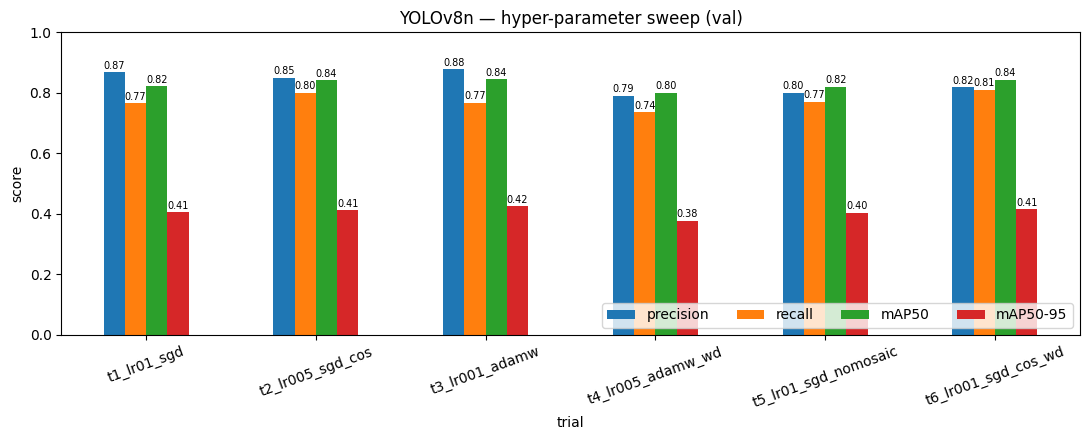

Best config by val mAP@50-95: t3_lr001_adamw → {'lr0': 0.001, 'optimizer': 'AdamW', 'cos_lr': True, 'close_mosaic': 10}


In [17]:
# ── Sweep plot + pick the winner (reads the persisted CSV, so it's resume-safe) ─
metric_cols = ["precision", "recall", "mAP50", "mAP50-95"]
res_df = load_progress().set_index("trial")
for c in metric_cols:
    res_df[c] = pd.to_numeric(res_df[c], errors="coerce")

tune_df = res_df.drop(index=["yolov8n_baseline", "yolov8n_FINAL"], errors="ignore")

ax = tune_df[metric_cols].plot(kind="bar", figsize=(11, 4.5), rot=20)
ax.set_title("YOLOv8n — hyper-parameter sweep (val)"); ax.set_ylim(0, 1)
ax.set_ylabel("score"); ax.legend(loc="lower right", ncol=4)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", padding=1, fontsize=7)
plt.tight_layout(); plt.show()

BEST_TRIAL = tune_df["mAP50-95"].idxmax()
BEST_CFG   = json.loads(res_df.loc[BEST_TRIAL, "config"])
print("Best config by val mAP@50-95:", BEST_TRIAL, "→", BEST_CFG)

,baseline (default),tuned (best),Δ abs,Δ %
precision,0.8561,0.8775,0.0214,2.5036
recall,0.7887,0.7671,-0.0216,-2.7376
mAP50,0.8408,0.8448,0.0040,0.4811
mAP50-95,0.4154,0.4245,0.0091,2.1923


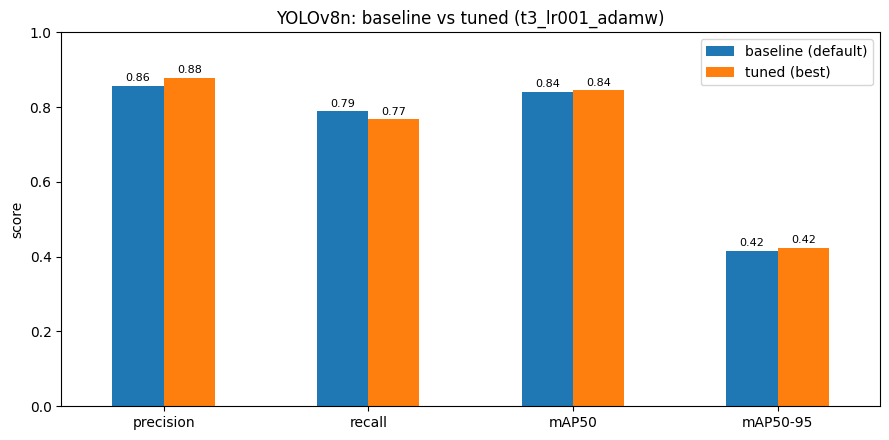

In [18]:
# ── Baseline vs tuned — did tuning help? ─────────────────────────────────────
base  = pd.to_numeric(pd.Series(baseline_metrics))[metric_cols]
tuned = tune_df.loc[BEST_TRIAL, metric_cols].astype(float)
cmp = pd.DataFrame({"baseline (default)": base, "tuned (best)": tuned})
cmp["\u0394 abs"] = cmp["tuned (best)"] - cmp["baseline (default)"]
cmp["\u0394 %"]   = 100 * cmp["\u0394 abs"] / cmp["baseline (default)"].replace(0, np.nan)
display(cmp.round(4))

ax = cmp[["baseline (default)", "tuned (best)"]].plot(kind="bar", figsize=(9, 4.5), rot=0)
ax.set_title(f"YOLOv8n: baseline vs tuned ({BEST_TRIAL})"); ax.set_ylim(0, 1); ax.set_ylabel("score")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", padding=2, fontsize=8)
plt.tight_layout(); plt.show()

## 6 · Optional — evolutionary (genetic) search

Ultralytics `.tune()` mutates hyper-parameters over `EVOLVE_ITERATIONS` generations and writes
`best_hyperparameters.yaml`. It is **heavier** than the manual grid — enable via
`RUN_EVOLUTION = True` (§4) only when you have the compute budget. It supports `resume=True` so an
interrupted genetic search can continue.

In [ ]:
# ── OPTIONAL genetic/evolutionary search (Ultralytics .tune()) ────────────────
# EVOLVED_CFG = None
# if RUN_EVOLUTION:
#     print(f"Running evolutionary search: {EVOLVE_ITERATIONS} iterations × {EPOCHS_TUNE} epochs …")
#     tune_kwargs = dict(
#         data=str(TUNE_YAML), imgsz=IMG_SIZE, epochs=EPOCHS_TUNE,
#         iterations=EVOLVE_ITERATIONS, optimizer="AdamW", device=DEVICE, seed=SEED,
#         plots=True, save=True, val=True, project=PROJECT_LOCAL, name="evolve")
#     try:
#         YOLO(BASELINE_WEIGHTS).tune(resume=RESUME, **tune_kwargs)      # newer ultralytics
#     except TypeError:
#         YOLO(BASELINE_WEIGHTS).tune(**tune_kwargs)                     # older: no resume kwarg
#     bh = Path(PROJECT_LOCAL) / "evolve" / "best_hyperparameters.yaml"
#     if bh.exists():
#         EVOLVED_CFG = yaml.safe_load(bh.read_text())
#         edst = TRIALS_DIR / "evolve"; edst.mkdir(parents=True, exist_ok=True)
#         shutil.copy(bh, edst / "best_hyperparameters.yaml")            # ← SAVE POINT
#         tr = Path(PROJECT_LOCAL) / "evolve" / "tune_results.csv"
#         if tr.exists(): shutil.copy(tr, edst / "tune_results.csv")
#         print("Evolved hyper-parameters saved to Drive:", edst)
#         print(EVOLVED_CFG)
#     else:
#         print("[!] best_hyperparameters.yaml not found — check the evolve run dir.")
# else:
#     print("Evolutionary search skipped (set RUN_EVOLUTION = True in §4 to enable).")

## 7 · Final model with the winning hyper-parameters

Retrain YOLOv8n with the best config on the full train split for a longer schedule
(`EPOCHS_FINAL`), then evaluate on the untouched **test** fold. Checkpointed like every other run.

To prefer the evolved config over the manual-grid winner, set `USE_EVOLVED = True` below.

In [19]:
# ── Consolidate the winning hyper-parameters and produce the FINAL weights ────
FINAL_CFG   = dict(BEST_CFG)
USE_EVOLVED = False
if USE_EVOLVED and EVOLVED_CFG:
    keep = ["lr0", "lrf", "momentum", "weight_decay", "warmup_epochs", "box", "cls", "dfl"]
    FINAL_CFG = {k: EVOLVED_CFG[k] for k in keep if k in EVOLVED_CFG}
print("FINAL hyper-parameters:", FINAL_CFG)

final_name    = "yolov8n_FINAL"
CKPT_FINAL_PT = TRIALS_DIR / final_name / "weights" / "best.pt"   # persisted copy (survives accounts)
prog = load_progress()

if (RESUME and final_name in set(prog["trial"]) and not FORCE_RERUN and CKPT_FINAL_PT.exists()):
    print("\u2713 Final model already trained — using checkpointed weights.")
    best_pt = CKPT_FINAL_PT
else:
    fres_metrics, FINAL_RUN_DIR = run_train(
        BASELINE_WEIGHTS, final_name, TUNE_YAML, EPOCHS_FINAL, **FINAL_CFG)
    ck = checkpoint_run(FINAL_RUN_DIR, final_name)
    save_trial_result({"trial": final_name, **fres_metrics, "epochs": EPOCHS_FINAL,
                       "config": json.dumps(FINAL_CFG), "run_dir": str(FINAL_RUN_DIR),
                       "weights": str(ck / "weights" / "best.pt"),
                       "timestamp": time.strftime("%Y-%m-%d %H:%M:%S")})   # ← SAVE POINT
    best_pt = ck / "weights" / "best.pt"
    print("Final (val):", {k: (round(v, 4) if v is not None else None)
                          for k, v in fres_metrics.items()})

assert best_pt.exists(), f"best.pt not found at {best_pt}"
test_metrics = YOLO(str(best_pt)).val(data=str(TUNE_YAML), split="test",
                                      imgsz=IMG_SIZE, device=DEVICE, verbose=False)
print("\n================ HELD-OUT TEST ================")
print(f"Precision : {test_metrics.box.mp:.4f}")
print(f"Recall    : {test_metrics.box.mr:.4f}")
print(f"mAP@50    : {test_metrics.box.map50:.4f}")
print(f"mAP@50-95 : {test_metrics.box.map:.4f}")
print("\nPer-class mAP@50-95:")
for i, name in enumerate(CLASS_NAMES):
    try:    print(f"  {name:9s}: {test_metrics.box.maps[i]:.4f}")
    except Exception: pass

FINAL hyper-parameters: {'lr0': 0.001, 'optimizer': 'AdamW', 'cos_lr': True, 'close_mosaic': 10}
Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/tune_data_full.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mode

Process Process-28:


KeyboardInterrupt: 

Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/process.py", line 317, in _bootstrap
    util._exit_function()


## 8 · Save the best hyperparameter weights as a **downloadable** file

We bundle the trained `best.pt` together with the exact `best_hyperparameters.yaml` into one zip,
copy it to the persistent Drive deliverables folder (a final save-point), and trigger a browser
download.

In [ ]:
# ── Export the BEST hyper-parameter weights as a downloadable bundle ──────────
final_name = "yolov8n_FINAL"
best_pt = TRIALS_DIR / final_name / "weights" / "best.pt"      # the single final file
if not best_pt.exists() and "FINAL_RUN_DIR" in dir():
    best_pt = FINAL_RUN_DIR / "weights" / "best.pt"
assert best_pt.exists(), f"best.pt not found at {best_pt} — run the §7 final-train cell first."

hp_yaml = DELIV_DIR / "best_hyperparameters.yaml"
hp_yaml.write_text(yaml.safe_dump(
    {"model": "yolov8n", "imgsz": IMG_SIZE, "epochs": EPOCHS_FINAL,
     "batch": BATCH, "seed": SEED, "selected_trial": BEST_TRIAL, **FINAL_CFG},
    sort_keys=False))

shutil.copy(best_pt, DELIV_DIR / "yolov8n_best.pt")            # persistent in THIS account's Drive

zip_path = DELIV_DIR / "m4_yolov8n_best_weights.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    z.write(best_pt, "yolov8n_best.pt")
    z.write(hp_yaml, "best_hyperparameters.yaml")

print("Final weights saved to THIS account's Drive:")
print("  ", DELIV_DIR / "yolov8n_best.pt")
print("Bundle:", zip_path, f"({zip_path.stat().st_size/1e6:.2f} MB)")

try:
    from google.colab import files
    files.download(str(zip_path))          # downloads best.pt + best_hyperparameters.yaml
except Exception as e:
    print("Auto-download unavailable — grab it from Drive at:", zip_path, "|", e)

### 8.1 · (Optional) Learning-curve overlay
Overlay the val mAP@50-95 curve of the baseline against the final tuned run for context.

In [ ]:
# ── Learning-curve overlay from the checkpointed results.csv files ──────────
def load_curve(run_csv: Path):
    if not run_csv.exists():
        return None
    d = pd.read_csv(run_csv); d.columns = [c.strip() for c in d.columns]
    col = next((c for c in d.columns if "mAP50-95" in c), None)
    return d[["epoch", col]].rename(columns={col: "mAP50-95"}) if col else None

plt.figure(figsize=(8, 4.5))
for tag, style in [("yolov8n_baseline", "--"), ("yolov8n_FINAL", "-")]:
    cur = load_curve(TRIALS_DIR / tag / "results.csv")
    if cur is not None:
        plt.plot(cur["epoch"], cur["mAP50-95"], style, lw=2.2, label=tag)
plt.xlabel("epoch"); plt.ylabel("val mAP@50-95"); plt.title("YOLOv8n — learning curves")
plt.legend(); plt.tight_layout(); plt.show()

## 9 · Report section (M4 write-up)

> Fill the bracketed numbers from your run outputs before submitting.

**Scope.** Milestone 4 — **hyperparameter tuning of the YOLOv8n baseline** (chosen in M3 as the
best accuracy-per-cost model for real-time in-cabin smoking/drinking detection). Tuning was run on
**100% of the train split**; val drove selection, test was held out.

**Search strategy.** A guided manual grid over the highest-leverage fine-tuning knobs
(`lr0`, `optimizer`, `cos_lr`, `mosaic`/`close_mosaic`, `weight_decay`), with an optional
evolutionary (genetic) refinement via Ultralytics `.tune()`. `imgsz` fixed at 640.

**Baseline vs tuned (full data, val).**

| Metric | Baseline (default) | Tuned (best) | Δ |
|---|---|---|---|
| Precision | [ ] | [ ] | [ ] |
| Recall | [ ] | [ ] | [ ] |
| mAP@50 | [ ] | [ ] | [ ] |
| mAP@50-95 | [ ] | [ ] | [ ] |

Winning config: **[BEST_TRIAL]** → `[BEST_CFG]`.

**Held-out test (final model).** Precision [ ] · Recall [ ] · mAP@50 [ ] · mAP@50-95 [ ]
(per-class mAP@50-95: smoking [ ], drinking [ ]).

**Engineering.** Every trial is checkpointed to Drive (`trial_results.csv` + `best.pt` + plots), so
a Colab disconnect resumes cleanly; a `tqdm` bar tracks the sweep. Final deliverable:
`m4_yolov8n_best_weights.zip` (weights + `best_hyperparameters.yaml`).

**Observation template.** Comment on which metric improved most, whether Recall (small cigarettes)
lagged Precision, and the accuracy/latency trade-off that keeps YOLOv8n the deployment choice.
